# Notebook to calculate exotic energy injection of different DM decaying into photons, the resulting CMB anisotropies, and the Fisher forecast.

Acknowledgement: I made use of Claude AI (Anthropic) for assistance in code debugging.

Imports and pointing DarkHistory to data directory needed to run the package

In [ ]:
%load_ext autoreload
import sys
sys.path.append("..")

import numpy as np
import os
os.environ["DH_DATA_DIR"] = "/Users/rxu/Desktop/212_final_proj/DHdata_hdf5"

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import pickle
from tqdm import tqdm_notebook as tqdm
from scipy.interpolate import interp1d

import darkhistory.main as main
from darkhistory.spec.spectrum import Spectrum
from darkhistory.low_energy.lowE_deposition import compute_fs
from darkhistory.low_energy.lowE_electrons import make_interpolator
import darkhistory.physics as phys
from darkhistory.history.tla import get_history


# For the Fisher forecast 
import CosmicFish.python.cosmicfish_pylib.fisher_matrix as fm
import CosmicFish.python.cosmicfish_pylib.fisher_operations as fo
import CosmicFish.python.cosmicfish_pylib.fisher_plot_analysis as fpa
import CosmicFish.python.cosmicfish_pylib.fisher_plot as fp

Planck 2018 Parameters 

In [4]:
phys.kB = 8.6173324e-5
phys.G = 6.6730e-8

phys.omega_m       = 0.3153
phys.omega_rad     = 8e-5
phys.omega_lambda  = 0.6847
phys.omega_baryon  = 0.02237/(phys.h**2)
phys.omega_DM      = 0.1200/(phys.h**2)

phys.rho_DM=phys.rho_crit*phys.omega_DM

phys.rho_baryon = phys.rho_crit*phys.omega_baryon
phys.nB = phys.rho_baryon/phys.mp

phys.YHe = 0.245

def TCMB(rs):
    fac = 2.7255
    return fac * phys.kB * rs

phys.TCMB = TCMB

In [ ]:
def save_as_pickled_object(obj, filepath):
    """
    This is a defensive way to write pickle.write, allowing for very large files on all platforms. Taken from DarkHistory examples module. 
    """
    max_bytes = 2**31 - 1
    bytes_out = pickle.dumps(obj)
    n_bytes = sys.getsizeof(bytes_out)
    with open(filepath, 'wb') as f_out:
        for idx in range(0, n_bytes, max_bytes):
            f_out.write(bytes_out[idx:idx+max_bytes])

Single DarkHistory run for mDM = 100 MeV to get energy deposition functions $$f_c$$ and the altered temperature and ionization histories. Can alter arguments depending on which effects we want to include (e.g backreaction, reionization, helium, etc.)

In [ ]:
mDM = 1e8

single_DH_run = main.evolve(
        primary='phot_delta',
        DM_process='decay', mDM=mDM, lifetime=3e25,
        start_rs = 3000, end_rs=4.000, helium_TLA = True, 
        coarsen_factor=1, backreaction=True, reion_switch = True
    )

  0%|          | 0/6621.0 [00:00<?, ?it/s]

 intdy--  t (=r1) illegal        
      in above message,  r1 =  0.9348326858396D+03
      t not in interval tcur - hu (= r1) to tcur (=r2)       
      in above,  r1 =  0.9348326858395D+03   r2 =  0.9347742295734D+03
 intdy--  t (=r1) illegal        
      in above message,  r1 =  0.9264569390637D+03
      t not in interval tcur - hu (= r1) to tcur (=r2)       
      in above,  r1 =  0.9264569390637D+03   r2 =  0.9263410740235D+03
 intdy--  t (=r1) illegal        
      in above message,  r1 =  0.9255309451987D+03
      t not in interval tcur - hu (= r1) to tcur (=r2)       
      in above,  r1 =  0.9255309451987D+03   r2 =  0.9254730705822D+03
 intdy--  t (=r1) illegal        
      in above message,  r1 =  0.8865766342654D+03
      t not in interval tcur - hu (= r1) to tcur (=r2)       
      in above,  r1 =  0.8865766342653D+03   r2 =  0.8863548792478D+03
 intdy--  t (=r1) illegal        
      in above message,  r1 =  0.8848052529686D+03
      t not in interval tcur - hu (= r1) to

Saving the results of the DarkHistory run in a pkl file

In [12]:
data_to_save = {
    'rs': single_DH_run['rs'],
    'fc': np.swapaxes(np.array(
        [single_DH_run['f'][channel]
        for channel in ['H ion', 'He ion', 'Lya', 'heat', 'cont']]
        ),0,1),
    'x': single_DH_run['x'],
    'Tm': single_DH_run['Tm'],
    'channels': ['H ion', 'He ion', 'Lya', 'heat', 'cont'],
}

save_as_pickled_object(data_to_save, r"/Users/rxu/Desktop/212_final_proj/f_c_DM_decay_100MeV_reion_backreaction.p") 

## Getting deposition functions standard way (works for high energy DM). Not used in this project, but good to know!!

In [ ]:
labels = ['phot_decay']

# Example input energy abscissa from DarkHistory examples module
log10eng0 = 3.6989700794219966
log10eng = np.array([log10eng0 + 0.23252559*i for i in np.arange(40)])
log10eng[-1] = 12.601505994846297

f_std_data = []
z_arr = None
x_data = []
Tm_data = []

In [ ]:
# center of mass energy
mass = 0
for i, eng in enumerate(tqdm(log10eng)):
    #injection energy, DM mass, center-of-mass energy
    Einj = 10**eng
    mDM = 2*Einj + 2*mass

    
    DH_run = main.evolve(
        primary = 'phot_delta',
        DM_process='decay', mDM=mDM, lifetime=3e25,
        start_rs = 3000, end_rs=4.000, reion_switch = True, helium_TLA = True,
        coarsen_factor=1, backreaction=True, cross_check = False,
        struct_boost=None
        )
    
    
    if z_arr is None:
        rs = DH_run['rs']  
        z_arr = rs - 1

    fc = np.swapaxes(np.array(
        [DH_run['f'][channel]
        for channel in ['H ion', 'He ion', 'Lya', 'heat', 'cont']]
        ),0,1)
    f_std_data.append(fc)

    x_data.append(DH_run['x'])
    Tm_data.append(DH_run['Tm'])

data_to_save = {
    'z': z_arr,
    'rs': z_arr + 1,
    'fc': np.array(f_std_data),
    'x': np.array(x_data),
    'Tm': np.array(Tm_data),
    'channels': ['H ion', 'He ion', 'Lya', 'heat', 'cont'],
    'log10eng': log10eng,
    'Einj_eV': 10**log10eng,
}

save_as_pickled_object(data_to_save, r"/Users/rxu/Desktop/212_final_proj/f_c_DM_decay_reion_backreaction.p") 

## Getting deposition functions for low energy photons. Used in this project. 

In [42]:
f_std_data_loweng = []
MEDEA_interp = make_interpolator(interp_type='2D', cross_check=False)

In [ ]:
def rs_to_dt_seconds(rs):
    """
    Convert an rs = 1+z grid into timestep widths dt in seconds,
    using dt = |drs| / (rs * H(rs)).
    """
    rs = np.asarray(rs, dtype=float)
    H = phys.H0 * np.sqrt(
        phys.omega_rad * rs**4 +
        phys.omega_m * rs**3 +
        phys.omega_lambda
    )
    drs = np.abs(np.gradient(rs))
    return drs / (rs * H)


def build_decay_power_history(photon_energies_eV, lifetime_s, rs, Omega_dcdmdr, Omega_cdm = 0.26):
    """
    Build dE/dVdt injected for monochromatic photon injection from DM decay,
    assuming chi -> gamma gamma, so mDM = 2 E_gamma.
    """
    photon_energies_eV = np.atleast_1d(np.array(photon_energies_eV, dtype=float))
    rs = np.asarray(rs, dtype=float)
    z = rs - 1.0
    mDM_eV = 2.0 * photon_energies_eV

    f_dcdm = Omega_dcdmdr / (Omega_cdm + Omega_dcdmdr)

    power_histories = np.empty((len(photon_energies_eV), len(rs)), dtype=float)
    for i, mDM in enumerate(mDM_eV):
        power_histories[i] = np.array([
            f_dcdm* phys.inj_rate('decay', r, mDM=mDM, lifetime=lifetime_s)
            for r in rs
        ])

    return {
        'rs': rs,
        'z': z,
        'Einj_eV': photon_energies_eV,
        'mDM_eV': mDM_eV,
        'dE_dVdt_inj': power_histories,
        'f_dcdm': f_dcdm,
    }


# helper functions for building background history 

def build_x_history_for_general_lowE(soln_history):
    """
    Convert get_history output columns
    [Tm, xHII, xHeII, xHeIII]
    into x = [xHI, xHeI, xHeII]
    in units of nH, as expected by lowE_deposition.compute_fs.
    """
    soln_history = np.asarray(soln_history, dtype=float)

    xHII = soln_history[:, 1]
    xHeII = soln_history[:, 2]
    xHeIII = soln_history[:, 3]

    xHI = 1.0 - xHII
    chi = phys.YHe / (4.0 * (1.0 - phys.YHe))   # nHe / nH
    xHeI = chi - xHeII - xHeIII

    return np.column_stack([xHI, xHeI, xHeII])


def build_baseline_history(rs, helium_TLA=True, reion_switch=True):
    """
    Standard baseline TLA history from DarkHistory.
    """
    return get_history(
        rs,
        helium_TLA=helium_TLA,
        reion_switch=reion_switch
    )


# helper functions for building the photon spectrum, which is used as a parameter in calculating the low energy deposition functions

def _bin_edges_from_centers(eng_grid_eV):
    """
    Construct approximate bin edges from monotonically increasing bin centers.
    Uses geometric means for interior edges, consistent with log grids.
    """
    eng_grid_eV = np.asarray(eng_grid_eV, dtype=float)

    if len(eng_grid_eV) < 2:
        raise ValueError("Energy grid must contain at least 2 points.")

    edges = np.zeros(len(eng_grid_eV) + 1, dtype=float)
    edges[1:-1] = np.sqrt(eng_grid_eV[:-1] * eng_grid_eV[1:])
    edges[0] = eng_grid_eV[0]**2 / edges[1]
    edges[-1] = eng_grid_eV[-1]**2 / edges[-2]
    return edges


def make_monochromatic_photon_spectrum_general(E_inj_eV, eng_grid_eV, rs, dE_dVdt_inj, dt):
    """
    Build a monochromatic photon Spectrum normalized for
    lowE_deposition.compute_fs.

    The total photon number per baryon injected during this timestep is

        Ntot = (dE/dVdt)_inj * dt / ( nB(z) * E_inj ).

    The monochromatic line is represented by splitting between the two nearest bins.
    Returned spectrum has spec_type='dNdE' (expected by DarkHistory).
    """
    eng_grid_eV = np.asarray(eng_grid_eV, dtype=float)
    dE_dVdt_inj = float(dE_dVdt_inj)
    dt = float(dt)
    rs = float(rs)

    if E_inj_eV <= 0:
        raise ValueError("E_inj_eV must be positive.")
    if dE_dVdt_inj < 0:
        raise ValueError("dE_dVdt_inj must be non-negative.")
    if dt <= 0:
        raise ValueError("dt must be positive.")

    nB_z = phys.nB * rs**3
    Ntot = dE_dVdt_inj * dt / (nB_z * E_inj_eV)

    dNdE = np.zeros_like(eng_grid_eV)
    edges = _bin_edges_from_centers(eng_grid_eV)
    dE = edges[1:] - edges[:-1]

    if E_inj_eV <= eng_grid_eV[0]:
        dNdE[0] = Ntot / dE[0]
    elif E_inj_eV >= eng_grid_eV[-1]:
        dNdE[-1] = Ntot / dE[-1]
    else:
        j = np.searchsorted(eng_grid_eV, E_inj_eV)
        e0, e1 = eng_grid_eV[j-1], eng_grid_eV[j]

        w1 = (E_inj_eV - e0) / (e1 - e0)
        w0 = 1.0 - w1

        dNdE[j-1] = Ntot * w0 / dE[j-1]
        dNdE[j]   = Ntot * w1 / dE[j]

    return Spectrum(eng_grid_eV, dNdE, rs=rs, spec_type='dNdE')


def make_zero_electron_spectrum(eng_grid_eV, rs):
    """
    Zero electron spectrum on the same energy grid.
    """
    eng_grid_eV = np.asarray(eng_grid_eV, dtype=float)
    return Spectrum(
        eng_grid_eV,
        np.zeros_like(eng_grid_eV),
        rs=rs,
        spec_type='dNdE'
    )


# main function for computation of fc of low energy photons

def fc_low_energy_general(
    E_inj_eV_list,
    lifetime_s,
    MEDEA_interp,
    out_dir=None,
    rs=None,
    start_rs=3000.0,
    end_rs=4.000,
    n_rs=1655,
    eng_grid_eV=None,
    history_override=None,
    reion_switch=True,
    helium_TLA=True,
    method='He',
    outfile_name="f_c_DM_decay_lowE_general.pkl",
):
    """
    Compute low-energy deposition fractions using
    darkhistory.low_energy.lowE_deposition.compute_fs.

    Parameters
    ----------
    E_inj_eV_list : array-like
        Injected photon energies (eV), assuming chi -> gamma gamma.
    lifetime_s : float
        DM lifetime in seconds.
    MEDEA_interp :
        Electron deposition interpolator required by lowE_electrons.
    out_dir : str or None
        Optional directory to save pickle.
    rs : array or None
        rs = 1+z grid. If None, build from start_rs/end_rs/n_rs.
    eng_grid_eV : array or None
        Energy grid for low-energy treatment.
    history_override : ndarray or None
        Optional history array [Tm, xHII, xHeII, xHeIII] to use instead of
        building a fresh baseline history. Used to find a full converged history. 
    method : {'no_He', 'He_recomb', 'He'}
        Helium treatment for general low-energy deposition. Specifics are in DarkHistory documentation. 
    """
    E_inj_eV_list = np.asarray(E_inj_eV_list, dtype=float)

    if rs is None:
        rs = np.linspace(start_rs, end_rs, n_rs)
    rs = np.asarray(rs, dtype=float)
    z = rs - 1.0

    if eng_grid_eV is None:
        # extend energy grid beyond 13.6 when using energies > 13.6 eV (hydrogen ionization threshold)
        emax = max(13.6, 1.05 * np.max(E_inj_eV_list))
        eng_grid_eV = np.logspace(-8, np.log10(emax), 2000)
    eng_grid_eV = np.asarray(eng_grid_eV, dtype=float)

    dt = rs_to_dt_seconds(rs)
    inj = build_decay_power_history(E_inj_eV_list, lifetime_s, rs, Omega_dcdmdr =0.001)

    if history_override is None:
        soln_history = build_baseline_history(
            rs,
            helium_TLA=helium_TLA,
            reion_switch=reion_switch
        )
    else:
        soln_history = np.asarray(history_override, dtype=float)

    x_history = build_x_history_for_general_lowE(soln_history)

    # fs returned by  compute_fs has order:
    # [H ion, He ion, Lya, heat, cont]
    fc_all = []

    for i, E_inj in enumerate(inj['Einj_eV']):
        fc_this_energy = []

        for j in range(len(rs)):
            phot_spec = make_monochromatic_photon_spectrum_general(
                E_inj_eV=E_inj,
                eng_grid_eV=eng_grid_eV,
                rs=rs[j],
                dE_dVdt_inj=inj['dE_dVdt_inj'][i, j],
                dt=dt[j],
            )

            elec_spec = make_zero_electron_spectrum(
                eng_grid_eV=eng_grid_eV,
                rs=rs[j]
            )

            fs = compute_fs(
                MEDEA_interp,
                elec_spec=elec_spec,
                phot_spec=phot_spec,
                x=np.asarray(x_history[j], dtype=float),
                dE_dVdt_inj=float(inj['dE_dVdt_inj'][i, j]),
                dt=float(dt[j]),
                highengdep=np.zeros(4),
                cmbloss=0.0,
                method=method,
                separate_higheng=False,
                cross_check=False,
            )

            fc_this_energy.append(np.asarray(fs, dtype=float))

        fc_this_energy = np.asarray(fc_this_energy)   # (nz, 5)
        fc_all.append(fc_this_energy)

    fc_all = np.asarray(fc_all)   # (nE, nz, 5)

    data_to_save = {
        'z': z,
        'rs': rs,
        'fc': fc_all,
        'channels': ['H ion', 'He ion', 'Lya', 'heat', 'cont'],
        'log10eng': np.log10(E_inj_eV_list),
        'Einj_eV': E_inj_eV_list,
        'mDM_eV': 2.0 * E_inj_eV_list,
        'dE_dVdt_inj': inj['dE_dVdt_inj'],
        'history_used': soln_history,          # [Tm, xHII, xHeII, xHeIII]
        'x_for_lowE': x_history,               # [xHI, xHeI, xHeII]
        'eng_grid_eV': eng_grid_eV,
        'method': method,
    }

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        outpath = os.path.join(out_dir, outfile_name)
        save_as_pickled_object(data_to_save, outpath)

    return data_to_save


# helper functions for iterating histories for convergence

def make_fc_callable(rs_grid, values):
    """
    Turn a tabulated fc(rs) into a callable accepted by get_history.
    """
    rs_grid = np.asarray(rs_grid, dtype=float)
    values = np.asarray(values, dtype=float)

    def f(rs, xHII=None, xHeII=None, xHeIII=None):
        return np.interp(rs, rs_grid, values)

    return f


def build_history_from_fc(
    data_fc,
    E_inj_eV,
    lifetime_s,
    Omega_dcdmdr,
    Omega_cdm,
    reion_switch=True,
    helium_TLA=True
):
    """
    Given a saved fc dataset and one selected energy, build a revised TLA history.

    Since get_history in DarkHistory does not receive an explicit decaying-DM abundance
    parameter, the amplitude normalization is incorporated into the effective deposition
    functions by scaling f_c -> f_dcdm * f_c.

    Parameters
    ----------
    data_fc : dict
        Contains at least 'rs', 'Einj_eV', 'fc'
    E_inj_eV : float
        Injected photon energy
    lifetime_s : float
        DM decay lifetime in seconds
    Omega_dcdmdr : float
       As defined in ExoCLASS: current fractional density of dcdm+dr (decaying cold dark matter and its relativistic decay radiation)
    Omega_cdm : float
        Density of cdm (cold dark matter)
    """
    rs = np.asarray(data_fc['rs'], dtype=float)
    Einj = np.asarray(data_fc['Einj_eV'], dtype=float)
    fc_all = np.asarray(data_fc['fc'], dtype=float)

    idx = np.argmin(np.abs(Einj - E_inj_eV))
    E_use = float(Einj[idx])
    fc = np.asarray(fc_all[idx], dtype=float)

    # decaying fraction / amplitude normalization
    f_dcdm = Omega_dcdmdr / (Omega_cdm + Omega_dcdmdr)

    # Scale the effective deposition functions by the decaying fraction
    f_H_ion   = make_fc_callable(rs, f_dcdm * fc[:, 0])
    f_He_ion  = make_fc_callable(rs, f_dcdm * fc[:, 1])
    f_H_exc   = make_fc_callable(rs, f_dcdm * fc[:, 2])
    f_heating = make_fc_callable(rs, f_dcdm * fc[:, 3])

    hist = get_history(
        rs,
        inj_particle='phot',
        DM_process='decay',
        mDM=2.0 * E_use,
        lifetime=lifetime_s,
        f_H_ion=f_H_ion,
        f_H_exc=f_H_exc,
        f_heating=f_heating,
        f_He_ion=f_He_ion,
        reion_switch=reion_switch,
        helium_TLA=helium_TLA,
    )

    return {
        'rs': rs,
        'z': rs - 1.0,
        'Einj_eV': E_use,
        'mDM_eV': 2.0 * E_use,
        'history': hist,   # [Tm, xHII, xHeII, xHeIII]
        'fc': fc,
        'f_dcdm': f_dcdm,
    }

def inspect_fc_data(data):
    fc_all = np.asarray(data['fc'], dtype=float)
    energies = np.asarray(data['Einj_eV'], dtype=float)
    channel_names = ['H ion', 'He ion', 'Lya', 'heat', 'cont']

    for i, E in enumerate(energies):
        fc = fc_all[i]
        row_sums = np.sum(fc, axis=1)

        print(f"\n=== E_inj = {E:.1f} eV ===")
        for j, name in enumerate(channel_names):
            arr = fc[:, j]
            print(f"{name:6s} min={np.min(arr):.6e} max={np.max(arr):.6e}")
        print("row sum min/max:", np.min(row_sums), np.max(row_sums))


def max_relative_history_change(hist_old, hist_new, eps=1e-30):
    """
    Compare two histories [Tm, xHII, xHeII, xHeIII].
    """
    hist_old = np.asarray(hist_old, dtype=float)
    hist_new = np.asarray(hist_new, dtype=float)

    rel = np.abs(hist_new - hist_old) / np.maximum(np.abs(hist_old), eps)
    return np.max(rel), rel



First pass of calculating the energy deposition functions for a given set of injection energies. 

In [ ]:
E_list = [10.2, 12.0, 14, 22.0, 100.0]

lifetime = np.log10(3e25)
lifetime_s = 10**lifetime
rs_vec = np.linspace(3000.0, 1.000, 2000)

data_pass1 = fc_low_energy_general(
    E_inj_eV_list=E_list,
    lifetime_s=lifetime_s,
    MEDEA_interp=MEDEA_interp,
    rs=rs_vec,
    history_override=None,
    method='He',
)

inspect_fc_data(data_pass1)


=== E_inj = 10.2 eV ===
H ion  min=0.000000e+00 max=0.000000e+00
He ion min=0.000000e+00 max=0.000000e+00
Lya    min=5.052309e-01 max=5.052309e-01
heat   min=0.000000e+00 max=0.000000e+00
cont   min=4.947636e-01 max=4.947636e-01
row sum min/max: 0.999994448230971 0.9999944482309719

=== E_inj = 12.0 eV ===
H ion  min=0.000000e+00 max=0.000000e+00
He ion min=0.000000e+00 max=0.000000e+00
Lya    min=9.999944e-01 max=9.999944e-01
heat   min=0.000000e+00 max=0.000000e+00
cont   min=0.000000e+00 max=0.000000e+00
row sum min/max: 0.9999944482309633 0.9999944482309642

=== E_inj = 14.0 eV ===
H ion  min=9.713037e-01 max=9.713037e-01
He ion min=2.868214e-06 max=2.868214e-06
Lya    min=2.868214e-06 max=2.868214e-06
heat   min=2.868214e-02 max=2.868214e-02
cont   min=2.868214e-06 max=2.868214e-06
row sum min/max: 0.9999944482309445 0.9999944482309455

=== E_inj = 22.0 eV ===
H ion  min=6.181387e-01 max=6.181387e-01
He ion min=3.817412e-05 max=3.817412e-05
Lya    min=3.817412e-05 max=3.817412e-0

Build revised history given the generated nergy deposition functions

In [44]:
revised_histories = {}

for E in E_list:
    revised_histories[E] = build_history_from_fc(
        data_pass1,
        E_inj_eV=E,
        lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26
    )
    print(f"Built revised history for {E:.1f} eV")

Built revised history for 10.2 eV
Built revised history for 12.0 eV
Built revised history for 14.0 eV
Built revised history for 22.0 eV
Built revised history for 100.0 eV


Second pass of generating energy deposition functions given the revised temperature and ionization histories

In [45]:
data_pass2 = {}

for E in E_list:
    hist_override = revised_histories[E]['history']

    data_pass2[E] = fc_low_energy_general(
        E_inj_eV_list=[E],
        lifetime_s=lifetime_s,
        MEDEA_interp=MEDEA_interp,
        rs=rs_vec,
        eng_grid_eV=data_pass1['eng_grid_eV'],
        history_override=hist_override,
        method='He',
    )

    print(f"Computed pass-2 fc for {E:.1f} eV")

Computed pass-2 fc for 10.2 eV
Computed pass-2 fc for 12.0 eV
Computed pass-2 fc for 14.0 eV
Computed pass-2 fc for 22.0 eV
Computed pass-2 fc for 100.0 eV


See if the histories for each energy has converged

In [46]:
for E in E_list:
    hist1 = revised_histories[E]['history']

    hist2_dict = build_history_from_fc(
        data_pass2[E],
        E_inj_eV=E,
        lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26
    )
    hist2 = hist2_dict['history']

    max_rel, _ = max_relative_history_change(hist1, hist2)
    print(f"{E:.1f} eV: max relative history change from pass1->pass2 history = {max_rel:.6e}")

10.2 eV: max relative history change from pass1->pass2 history = 0.000000e+00
12.0 eV: max relative history change from pass1->pass2 history = 0.000000e+00
14.0 eV: max relative history change from pass1->pass2 history = 0.000000e+00
22.0 eV: max relative history change from pass1->pass2 history = 0.000000e+00
100.0 eV: max relative history change from pass1->pass2 history = 2.285436e-02


The 100 eV case did not converge as nicely as the other energies, so build another revised history and run a third pass of the energy deposition functions specifically for 100 eV (optional if histories already converged)

In [ ]:
hist_pass3_100 = build_history_from_fc(
    data_pass2[100.0],
    E_inj_eV=100.0,
    lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26,
)

data_pass3_100 = fc_low_energy_general(
    E_inj_eV_list=[100.0],
    lifetime_s=lifetime_s,
    MEDEA_interp=MEDEA_interp,
    rs=rs_vec,
    eng_grid_eV=data_pass1['eng_grid_eV'],
    history_override=hist_pass3_100['history'],
    method='He',
)

print("Computed pass-3 fc for 100 eV")

Computed pass-3 fc for 100 eV


In [49]:
# pass-2 revised history for 100 eV
hist2_100 = revised_histories[100.0]['history']

# build the history implied by pass-3 fc
hist3_dict = build_history_from_fc(
    data_pass3_100,
    E_inj_eV=100.0,
    lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26
)
hist3_100 = hist3_dict['history']

max_rel_100, rel_100 = max_relative_history_change(hist2_100, hist3_100)
print("100 eV: max relative history change from pass2->pass3 history =", f"{max_rel_100:.6e}")

100 eV: max relative history change from pass2->pass3 history = 3.226418e-02


Diagnostic tests for where the change in the history is coming from for 100 eV. 

In [50]:
col_names = ["Tm", "xHII", "xHeII", "xHeIII"]

imax = np.unravel_index(np.argmax(rel_100), rel_100.shape)
jmax, cmax = imax

print("largest relative change =", rel_100[jmax, cmax])
print("at z =", rs_vec[jmax] - 1.0)
print("column =", col_names[cmax])
print("pass2 value =", hist2_100[jmax, cmax])
print("pass3 value =", hist3_100[jmax, cmax])

largest relative change = 0.03226417914883319
at z = 654.1090545272637
column = xHeII
pass2 value = 1.4409331443310247e-07
pass3 value = 1.4874236694412124e-07


In [51]:
hist2_100 = revised_histories[100.0]["history"]
hist3_100 = hist3_dict["history"]

absdiff = np.abs(hist3_100 - hist2_100)
col_names = ["Tm", "xHII", "xHeII", "xHeIII"]

for i, name in enumerate(col_names):
    print(name, "max abs change =", np.max(absdiff[:, i]))

Tm max abs change = 0.00045510575305866136
xHII max abs change = 6.433203252065312e-05
xHeII max abs change = 3.445879043162403e-06
xHeIII max abs change = 3.4456309782326944e-06


Running other iteration of 100 eV

In [52]:
# Build the revised history from the 100 eV pass-3 fc
hist_pass4_100 = build_history_from_fc(
    data_pass3_100,
    E_inj_eV=100.0,
    lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26
)

# Run pass 4 for 100 eV using that revised history
data_pass4_100 = fc_low_energy_general(
    E_inj_eV_list=[100.0],
    lifetime_s=lifetime_s,
    MEDEA_interp=MEDEA_interp,
    rs=rs_vec,
    eng_grid_eV=data_pass1['eng_grid_eV'],
    history_override=hist_pass4_100['history'],
    method='He',
)

print("Computed pass-4 fc for 100 eV")

Computed pass-4 fc for 100 eV


In [ ]:
# pass 3 history
hist3_100 = hist3_dict['history']

# pass 4 history 
hist4_dict = build_history_from_fc(
    data_pass4_100,
    E_inj_eV=100.0,
    lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26
)
hist4_100 = hist4_dict['history']

max_rel_100_34, rel_100_34 = max_relative_history_change(hist3_100, hist4_100)
print("100 eV: max relative history change from pass3->pass4 history =", f"{max_rel_100_34:.6e}")

absdiff_34 = np.abs(hist4_100 - hist3_100)
col_names = ["Tm", "xHII", "xHeII", "xHeIII"]

for i, name in enumerate(col_names):
    print(name, "max abs change =", np.max(absdiff_34[:, i]))

100 eV: max relative history change from pass3->pass4 history = 2.132996e-02
Tm max abs change = 0.00045076269424489807
xHII max abs change = 2.802762966147565e-05
xHeII max abs change = 9.900024974668353e-07
xHeIII max abs change = 6.941598668652738e-07


Collect final histories and energy deposition functions for all energies depending on which pass it converged on

In [54]:
final_data_by_energy = {
    10.2: data_pass2[10.2],
    12.0: data_pass2[12.0],
    14.0: data_pass2[14.0],
    22.0: data_pass2[22.0],
    100.0: data_pass4_100,
}

Making sure that all the row sums to order 1 (so nothing weird happened in the DarkHistory calculation)

In [55]:
for E in [10.2, 12.0, 14.0, 22.0, 100.0]:
    print(f"\n##### FINAL VALIDATION: {E:.1f} eV #####")
    inspect_fc_data(final_data_by_energy[E])


##### FINAL VALIDATION: 10.2 eV #####

=== E_inj = 10.2 eV ===
H ion  min=0.000000e+00 max=0.000000e+00
He ion min=0.000000e+00 max=0.000000e+00
Lya    min=5.052309e-01 max=5.052309e-01
heat   min=0.000000e+00 max=0.000000e+00
cont   min=4.947636e-01 max=4.947636e-01
row sum min/max: 0.999994448230971 0.9999944482309719

##### FINAL VALIDATION: 12.0 eV #####

=== E_inj = 12.0 eV ===
H ion  min=0.000000e+00 max=0.000000e+00
He ion min=0.000000e+00 max=0.000000e+00
Lya    min=9.999944e-01 max=9.999944e-01
heat   min=0.000000e+00 max=0.000000e+00
cont   min=0.000000e+00 max=0.000000e+00
row sum min/max: 0.9999944482309633 0.9999944482309642

##### FINAL VALIDATION: 14.0 eV #####

=== E_inj = 14.0 eV ===
H ion  min=9.713037e-01 max=9.713037e-01
He ion min=2.868214e-06 max=2.868214e-06
Lya    min=2.868214e-06 max=2.868214e-06
heat   min=2.868214e-02 max=2.868214e-02
cont   min=2.868214e-06 max=2.868214e-06
row sum min/max: 0.9999944482309445 0.9999944482309455

##### FINAL VALIDATION: 22.0

# Generating reionization histories compatible for running in ExoCLASS

In [ ]:
# helpers to convert from DarkHistory format to a format compatible with running ExoCLASS

def darkhistory_history_to_xe(history_arr):
    """
    Convert DarkHistory history columns
    [Tm, xHII, xHeII, xHeIII]
    into xe = ne / nH = xHII + xHeII + 2*xHeIII
    """
    history_arr = np.asarray(history_arr, dtype=float)

    xHII = history_arr[:, 1]
    xHeII = history_arr[:, 2]
    xHeIII = history_arr[:, 3]

    xe = xHII + xHeII + 2.0 * xHeIII
    return xe


def make_reio_inter_arrays(rs, history_arr, zmax=30.0, npts=80):
    """
    Build ExoCLASS reio_inter_z and reio_inter_xe arrays
    from a DarkHistory history.

    Parameters
    ----------
    rs : array
        rs = 1+z grid
    history_arr : ndarray
        DarkHistory history with columns [Tm, xHII, xHeII, xHeIII]
    zmax : float
        Maximum redshift up to which to override the ionization history
    npts : int
        Number of interpolation points for reio_inter

    Returns
    -------
    z_grid, xe_grid : arrays
        Ready for ExoCLASS reio_inter_z / reio_inter_xe
    """
    rs = np.asarray(rs, dtype=float)
    z = rs - 1.0
    xe = darkhistory_history_to_xe(history_arr)

    # sort ascending in z for CLASS
    order = np.argsort(z)
    z = z[order]
    xe = xe[order]

    # keep only low-z part
    sel = z <= zmax
    z_low = z[sel]
    xe_low = xe[sel]

    if len(z_low) < 2:
        raise ValueError(f"Not enough z points below zmax={zmax} to build reio_inter arrays.")

    # interpolate onto a regular grid
    z_grid = np.linspace(0.0, zmax, npts)
    xe_grid = np.interp(z_grid, z_low, xe_low)

    # CLASS expects the last x_e entry to be 0 so it joins
    # onto the standard recombination history above zmax
    xe_grid[-1] = 0.0

    return z_grid, xe_grid


def format_class_list(arr, fmt="{:.6g}"):
    return ", ".join(fmt.format(x) for x in arr)

In [56]:
final_histories_by_energy = {}

for E in [10.2, 12.0, 14.0, 22.0, 100.0]:
    final_histories_by_energy[E] = build_history_from_fc(
        final_data_by_energy[E],
        E_inj_eV=E,
        lifetime_s=lifetime_s, Omega_dcdmdr = 0.001, Omega_cdm = 0.26
    )

    print(f"Built final converged history for {E:.1f} eV")

Built final converged history for 10.2 eV
Built final converged history for 12.0 eV
Built final converged history for 14.0 eV
Built final converged history for 22.0 eV
Built final converged history for 100.0 eV


In [105]:
reio_inter_by_energy = {}

for E in [10.2, 12.0, 14.0, 22.0, 100.0]:
    rs = final_histories_by_energy[E]["rs"]
    hist = final_histories_by_energy[E]["history"]

    z_grid, xe_grid = make_reio_inter_arrays(
        rs=rs,
        history_arr=hist,
        zmax=30.0,   # you can change this if you want
        npts=80
    )

    reio_inter_by_energy[E] = {
        "z_grid": z_grid,
        "xe_grid": xe_grid
    }

    print(f"Made reio_inter arrays for {E:.1f} eV")

Made reio_inter arrays for 10.2 eV
Made reio_inter arrays for 12.0 eV
Made reio_inter arrays for 14.0 eV
Made reio_inter arrays for 22.0 eV
Made reio_inter arrays for 100.0 eV


Creating .ini files for ExoCLASS

In [ ]:
# helper functions for formatting the ini files that will be used to generate CMB anisotropies from ExoCLASS
def format_class_list_ascii(arr):
    arr = np.asarray(arr, dtype=float)
    if not np.all(np.isfinite(arr)):
        bad = np.where(~np.isfinite(arr))[0]
        raise ValueError(f"Non-finite entries at indices: {bad}")
    return ", ".join(f"{x:.8e}" for x in arr)

def write_reio_inter_ini(
    path,
    z_grid,
    xe_grid,
    root="output/decay_10.2eV_"
):
    z_grid = np.asarray(z_grid, dtype=float)
    xe_grid = np.asarray(xe_grid, dtype=float)

    if len(z_grid) != len(xe_grid):
        raise ValueError("z_grid and xe_grid must have the same length")

    text = f"""h = 0.67556
T_cmb = 2.7255
omega_b = 0.022032
N_ur = 3.046
omega_cdm = 0.12038

A_s = 1.99405e-9
n_s = 0.9649

Omega_dcdmdr = 0.0
tau_dcdm = 0.0
decay_fraction = 0.0

YHe = BBN
recombination = HyRec

reio_parametrization = reio_inter
reio_inter_num = {len(z_grid)}
reio_inter_z = {format_class_list_ascii(z_grid)}
reio_inter_xe = {format_class_list_ascii(xe_grid)}

star_heating_parametrization = heating_none

annihilation = 0.
PBH_fraction = 0.

output = tCl,pCl,lCl
lensing = yes
l_max_scalars = 3000

root = {root}
headers = yes
format = class
write thermodynamics = yes
write parameters = yes
write warnings = yes

input_verbose = 1
background_verbose = 1
thermodynamics_verbose = 1
perturbations_verbose = 1
transfer_verbose = 1
primordial_verbose = 1
spectra_verbose = 1
nonlinear_verbose = 1
lensing_verbose = 1
output_verbose = 1
"""
    with open(path, "w", encoding="ascii", newline="\n") as f:
        f.write(text)

In [111]:
z_grid, xe_grid = make_reio_inter_arrays(
    rs=final_histories_by_energy[10.2]["rs"],
    history_arr=final_histories_by_energy[10.2]["history"],
    zmax=30.0,
    npts=20,
)

write_reio_inter_ini(
    "/Users/rxu/Desktop/212_final_proj/class/DM_decay_10.2eV_As_minus.ini",
    z_grid,
    xe_grid,
    root="output/decay_10.2eV_As_minus_"
)

In [43]:
for E in [10.2, 12.0, 14.0, 22.0, 100.0]:
    z_grid = reio_inter_by_energy[E]["z_grid"]
    xe_grid = reio_inter_by_energy[E]["xe_grid"]
    plt.plot(z_grid, xe_grid, label=f"{E:.1f} eV")

plt.xlabel("z")
plt.ylabel(r"$x_e = n_e / n_H$")
plt.legend()
plt.show()

/var/folders/06/h849jt9s1_v93r97zxz6fqh80000gn/T/ipykernel_64758/2210625055.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Diagnostic tests and plots for looking at the change in free electron fraction given an injection energy

In [72]:
def history_to_xe(history_arr):
    """
    DarkHistory history columns:
      [Tm, xHII, xHeII, xHeIII]

    Returns:
      xe = ne / nH = xHII + xHeII + 2*xHeIII
    """
    history_arr = np.asarray(history_arr, dtype=float)

    xHII = history_arr[:, 1]
    xHeII = history_arr[:, 2]
    xHeIII = history_arr[:, 3]

    xe = xHII + xHeII + 2.0 * xHeIII
    return xe

In [120]:
baseline_history = data_pass1["history_used"]   # or build_baseline_history(rs_vec)
z_baseline = data_pass1["rs"] - 1.0
xe_baseline = history_to_xe(baseline_history)
energies = [22.0, 100.0]

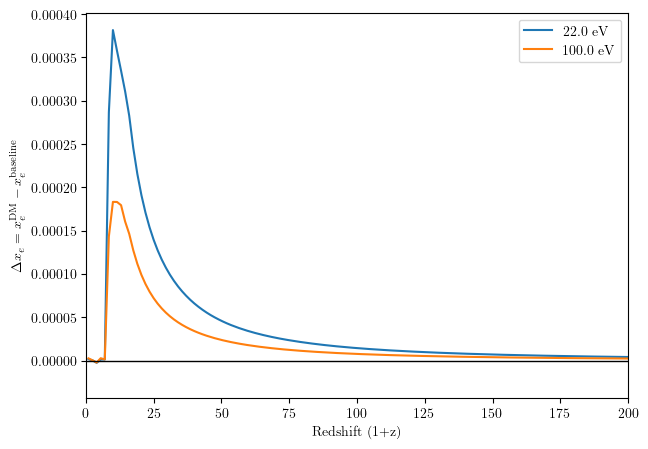

In [122]:
plt.figure(figsize=(7,5))

for E in energies:
    z = final_histories_by_energy[E]["rs"] - 1.0
    xe = history_to_xe(final_histories_by_energy[E]["history"])

    # interpolate baseline onto same z grid 
    xe_base_interp = np.interp(z, z_baseline[::-1], xe_baseline[::-1]) if np.any(np.diff(z_baseline) < 0) else np.interp(z, z_baseline, xe_baseline)
    delta_xe = xe - xe_base_interp

    plt.plot(1+z, delta_xe, label=f"{E:.1f} eV")

plt.axhline(0.0, color="k", linewidth=1)
plt.xlim(0, 200)
plt.xlabel("Redshift (1+z)")
plt.ylabel(r"$\Delta x_e = x_e^{\rm DM} - x_e^{\rm baseline}$")
plt.legend()
plt.savefig('Delta_x_e.pdf', dpi = 700)
plt.show()

In [79]:
for E in energies:
    z = final_histories_by_energy[E]["rs"] - 1.0
    xe = history_to_xe(final_histories_by_energy[E]["history"])

    xe_base_interp = np.interp(z, z_baseline[::-1], xe_baseline[::-1]) if np.any(np.diff(z_baseline) < 0) else np.interp(z, z_baseline, xe_baseline)
    delta_xe = xe - xe_base_interp

    imax = np.argmax(delta_xe)
    print(f"{E:.1f} eV: max delta_xe = {delta_xe[imax]:.6e} at z = {z[imax]:.4f}")

10.2 eV: max delta_xe = 1.113413e-05 at z = 1359.2266
12.0 eV: max delta_xe = 1.323799e-05 at z = 1416.2361
14.0 eV: max delta_xe = 5.085107e-04 at z = 10.5018
22.0 eV: max delta_xe = 3.814968e-04 at z = 9.0015
100.0 eV: max delta_xe = 1.831497e-04 at z = 9.0015


In [82]:
for E in energies:
    z = final_histories_by_energy[E]["rs"] - 1.0
    xe = history_to_xe(final_histories_by_energy[E]["history"])

    xe_base_interp = np.interp(z, z_baseline[::-1], xe_baseline[::-1]) if np.any(np.diff(z_baseline) < 0) else np.interp(z, z_baseline, xe_baseline)
    delta_xe = xe - xe_base_interp

    mask = (z >= 6) & (z <= 20)
    avg = np.mean(delta_xe[mask])
    print(f"{E:.1f} eV: mean delta_xe over 6<=z<=20 = {avg:.6e}")

10.2 eV: mean delta_xe over 6<=z<=20 = -6.924895e-07
12.0 eV: mean delta_xe over 6<=z<=20 = -4.513802e-07
14.0 eV: mean delta_xe over 6<=z<=20 = 3.702561e-04
22.0 eV: mean delta_xe over 6<=z<=20 = 2.606449e-04
100.0 eV: mean delta_xe over 6<=z<=20 = 1.334378e-04


## Temperature and reionization history plots

DarkHistory's default reionization model (for reference purposes)

In [ ]:
rs_vec = np.linspace(3000.0, 4.000, 2000)
soln_default_reion = get_history(
rs_vec, helium_TLA=True, reion_switch=True
)

data_to_save = {
    "rs": rs_vec,
    "z": rs_vec - 1,
    "history": soln_default_reion,
}
save_as_pickled_object(data_to_save, r"/Users/rxu/Desktop/212_final_proj/f_c_default_reion_history.p")

Opening the .pkl files from the DarkHistory runs with $m_\chi = 100$ MeV, with different effects

In [ ]:
with open('/Users/rxu/Desktop/212_final_proj/f_c_DM_decay_100MeV_only.p', "rb") as f:
    obj = pickle.load(f)

with open('/Users/rxu/Desktop/212_final_proj/f_c_DM_decay_100MeV_reion_backreaction.p', "rb") as f:
    obj2 = pickle.load(f)

with open('/Users/rxu/Desktop/212_final_proj/f_c_DM_decay_100MeV_backreaction.p', "rb") as f:
    obj3 = pickle.load(f)

with open('/Users/rxu/Desktop/212_final_proj/f_c_DM_decay_100MeV_reion.p', "rb") as f:
    obj4 = pickle.load(f)

with open("/Users/rxu/Desktop/212_final_proj/f_c_default_reion_history.p", "rb") as f:
    data = pickle.load(f)


# histories from low-energy DM decay
rs_24eV = final_histories_by_energy[10.2]['rs']
tm_24eV = final_histories_by_energy[10.2]['history'][:, 0]
xHII_24eV = final_histories_by_energy[10.2]['history'][:, 1]


# histories from default reionization model 
rs_default = data['rs']
history_default= data['history']

Tm_default = history_default[:, 0]    # temperature in eV
xHII_default = history_default[:, 1]  # hydrogen ionization fraction
xHeII = history_default[:, 2]
xHeIII = history_default[:, 3]

Pretty plotting code!

In [15]:
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']

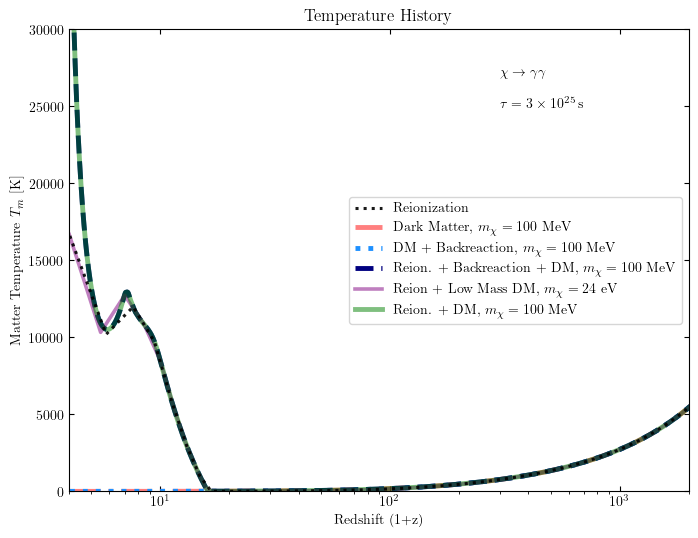

In [114]:
plt.close()
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Temperature History')
ax.plot(rs_default, Tm_default*11606, color='black', linestyle='dotted', linewidth=2.2, label='Reionization', alpha=0.9, zorder=5)
ax.plot(obj['rs'], obj['Tm']*11606, color='red', linestyle='-.', linewidth=3.5, label=r'Dark Matter, $m_\chi = 100$ MeV', alpha=0.5, zorder=2)
ax.plot(obj3['rs'], obj3['Tm']*11606, color='dodgerblue', linestyle=':', linewidth=3.5, label=r'DM + Backreaction, $m_\chi = 100$ MeV', zorder=2)
ax.plot(obj2['rs'], obj2['Tm']*11606, color='navy', linestyle='--', linewidth=3.5, label=r'Reion. + Backreaction + DM, $m_\chi = 100$ MeV', zorder=2)
ax.plot(rs_24eV, tm_24eV*11606, color = 'purple', linestyle='-', linewidth=2.6, label = r'Reion + Low Mass DM, $m_\chi = 24$ eV', alpha = 0.5)
ax.plot(obj4['rs'], obj4['Tm']*11606, color='green', linewidth=3.5, label=r'Reion. + DM, $m_\chi = 100$ MeV', alpha=0.5, zorder=2)

ax.text(300, 27000, r'$\chi \to \gamma\gamma$')
ax.text(300, 25000, r'$\tau = 3 \times 10^{25}\,\mathrm{s}$')
ax.set_xlabel("Redshift (1+z)")
ax.set_xlim(4, 2000)
ax.set_ylim(-2, 30000)
ax.set_xscale('log')
ax.set_ylabel(r"Matter Temperature $T_m$ [K]")
ax.tick_params(direction='in', top=True, right=True)
ax.legend()

plt.savefig('temperature_history.pdf', dpi=700)
plt.show()

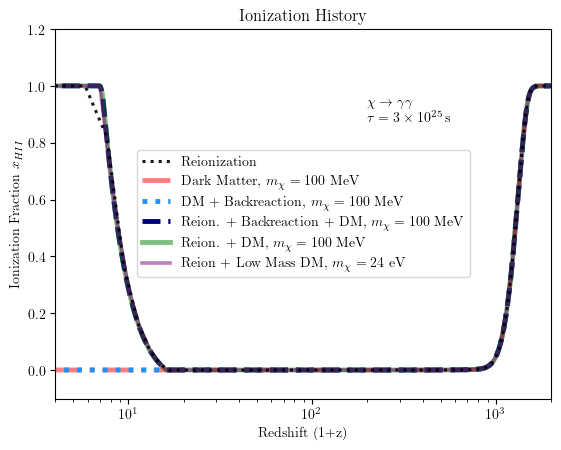

In [117]:
plt.close()
plt.title('Ionization History')
plt.xlabel("Redshift (1+z)")
plt.plot(rs_default, xHII_default, color = 'black', linestyle='dotted', linewidth=2.2, label='Reionization', alpha=0.9, zorder=5)
plt.plot(obj['rs'], obj['x'][:, 0], color = 'red', linestyle='-.', linewidth=3.5, label=r'Dark Matter, $m_\chi = 100$ MeV', alpha=0.5, zorder=2)
plt.plot(obj3['rs'], obj3['x'][:, 0], color = 'dodgerblue', linestyle=':', linewidth=3.5, label=r'DM + Backreaction, $m_\chi = 100$ MeV', zorder=2)
plt.plot(obj2['rs'], obj2['x'][:, 0], color = 'navy',  linestyle="--", linewidth=3.5, label=r'Reion. + Backreaction + DM, $m_\chi = 100$ MeV', zorder=2)
plt.plot(obj4['rs'], obj4['x'][:, 0], color='green', linewidth=3.5, label=r'Reion. + DM, $m_\chi = 100$ MeV', alpha=0.5, zorder=2)
plt.plot(rs_24eV, xHII_24eV, color = 'purple', linestyle='-', linewidth=2.6, label = r'Reion + Low Mass DM, $m_\chi = 24$ eV', alpha = 0.5)
plt.text(200, 0.93, r'$\chi \to \gamma\gamma$')
plt.text(200, 0.88, r'$\tau = 3\times10^{25}\,\mathrm{s}$')
plt.xscale('log')
plt.xlim(4, 2000)
plt.ylim(-0.1, 1.2)
plt.ylabel(r"Ionization Fraction $x_{HII}$")
plt.legend()
plt.savefig(f'ionization_history.pdf', dpi=700)
plt.show()

## CMB Anisotropies Plots

In [98]:
cl_base = np.loadtxt("class/output/baseline_cl_lensed.dat")
cl_dm = np.loadtxt("class/output/decay_10.2eV_cl_lensed.dat")
cl_dm_2 = np.loadtxt("class/output/decay_12.0eV_cl_lensed.dat")
cl_dm_3 = np.loadtxt("class/output/decay_14.0eV_cl_lensed.dat")
cl_dm_4 = np.loadtxt("class/output/decay_22.0eV_cl_lensed.dat")
cl_dm_5 = np.loadtxt("class/output/decay_100.0eV_cl_lensed.dat")

ell_base = cl_base[:, 0]
TT_base = cl_base[:, 1]

ell_dm = cl_dm[:, 0]
TT_dm = cl_dm[:, 1]

ell_dm_2 = cl_dm_2[:, 0]
TT_dm_2 = cl_dm_2[:, 1]

ell_dm_3 = cl_dm_3[:, 0]
TT_dm_3 = cl_dm_3[:, 1]

ell_dm_4 = cl_dm_4[:, 0]
TT_dm_4= cl_dm_4[:, 1]

ell_dm_5 = cl_dm_5[:, 0]
TT_dm_5 = cl_dm_5[:, 1]

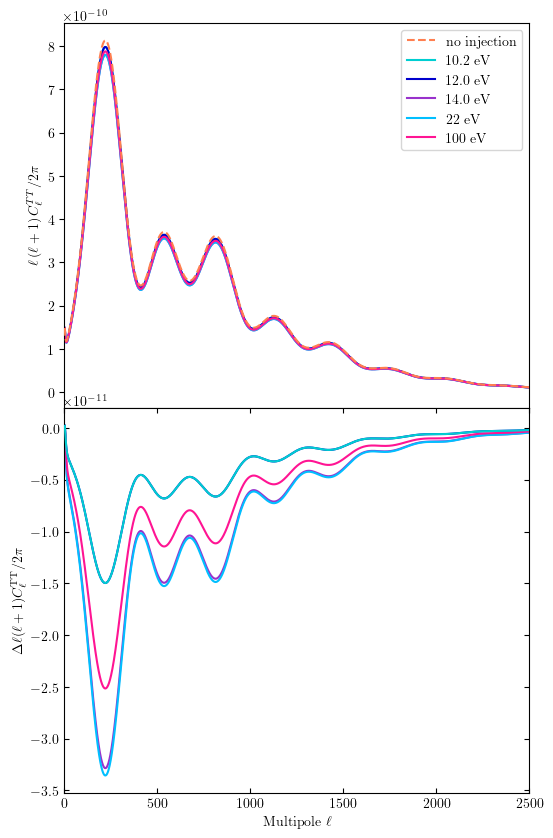

In [99]:
fig = plt.figure(figsize=(6, 10))
gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)


ax1.plot(ell_base, TT_base, color = 'coral', linestyle = '--', label="no injection", zorder =3)
ax1.plot(ell_dm, TT_dm, color = 'darkturquoise', label="10.2 eV", zorder = 2)
ax1.plot(ell_dm_2, TT_dm_2, color = 'mediumblue', label="12.0 eV")
ax1.plot(ell_dm_3, TT_dm_3, color = 'darkorchid', label="14.0 eV")
ax1.plot(ell_dm_4, TT_dm_4, color = 'deepskyblue', label="22 eV")
ax1.plot(ell_dm_5, TT_dm_5, color = 'deeppink', label="100 eV")
ax1.set_ylabel(r'$\ell\left(\ell +1\right)C^{TT}_{\ell}/ 2\pi$ ')


ax2.plot(ell_dm, TT_dm-TT_base, color = 'darkturquoise', label="10.2 eV", zorder = 3)
ax2.plot(ell_dm_2, TT_dm_2-TT_base, color = 'mediumblue', label="12.0 eV", zorder =2)
ax2.plot(ell_dm_3, TT_dm_3-TT_base, color = 'darkorchid', label="13.6 eV")
ax2.plot(ell_dm_4, TT_dm_4-TT_base, color = 'deepskyblue', label="22 eV")
ax2.plot(ell_dm_5, TT_dm_5-TT_base, color = 'deeppink', label="100 eV")
ax2.set_xlabel(r'Multipole $\ell$')
ax2.set_ylabel(r'$\Delta \ell(\ell+1)C_\ell^{\mathrm{TT}}/2\pi$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax = plt.gca()
ax.tick_params(direction='in', top=True, right=True)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 2500)
ax1.tick_params(labelbottom=False)
plt.savefig(f'CMB_TT_spectra.pdf', dpi = 700)
plt.show()

In [100]:
EE_base = cl_base[:, 2]
EE_dm = cl_dm[:, 2]
EE_dm_2 = cl_dm_2[:, 2]
EE_dm_3 = cl_dm_3[:, 2]
EE_dm_4 = cl_dm_4[:, 2]
EE_dm_5 = cl_dm_5[:, 2]

TE_base = cl_base[:, 4]
TE_dm = cl_dm[:, 4]
TE_dm_2 = cl_dm_2[:, 4]
TE_dm_3 = cl_dm_3[:, 4]
TE_dm_4 = cl_dm_4[:, 4]
TE_dm_5 = cl_dm_5[:, 4]

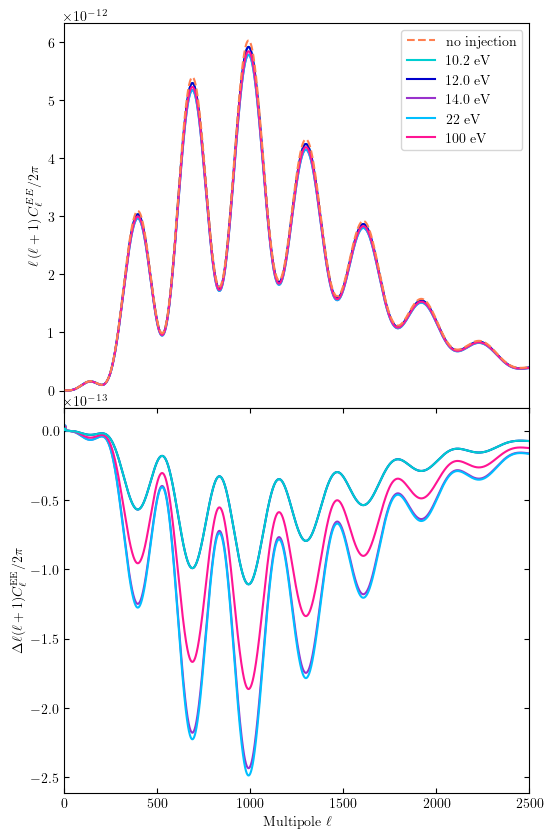

In [101]:
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']

fig = plt.figure(figsize=(6, 10))
gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)


ax1.plot(ell_base, EE_base, color = 'coral', linestyle = '--', label="no injection", zorder = 3)
ax1.plot(ell_dm, EE_dm, color = 'darkturquoise', label="10.2 eV")
ax1.plot(ell_dm_2, EE_dm_2, color = 'mediumblue', label="12.0 eV")
ax1.plot(ell_dm_3, EE_dm_3, color = 'darkorchid', label="14.0 eV")
ax1.plot(ell_dm_4, EE_dm_4, color = 'deepskyblue', label="22 eV")
ax1.plot(ell_dm_5, EE_dm_5, color = 'deeppink', label="100 eV")
ax1.set_ylabel(r'$\ell\left(\ell +1\right)C^{EE}_{\ell}/ 2\pi$')


ax2.plot(ell_dm, EE_dm-EE_base, color = 'darkturquoise', label="10.2 eV", zorder = 3)
ax2.plot(ell_dm_2, EE_dm_2-EE_base, color = 'mediumblue', label="12.0 eV", zorder = 2)
ax2.plot(ell_dm_3, EE_dm_3-EE_base, color = 'darkorchid', label="14.0 eV")
ax2.plot(ell_dm_4, EE_dm_4-EE_base, color = 'deepskyblue', label="22 eV")
ax2.plot(ell_dm_5, EE_dm_5-EE_base, color = 'deeppink',  label="100 eV")
ax2.set_xlabel(r'Multipole $\ell$')
ax2.set_ylabel(r'$\Delta \ell(\ell+1)C_\ell^{\mathrm{EE}}/2\pi$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax = plt.gca()
ax.tick_params(direction='in', top=True, right=True)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 2500)
ax1.tick_params(labelbottom=False)
plt.savefig(f'CMB_EE_spectra.pdf', dpi = 700)
plt.show()

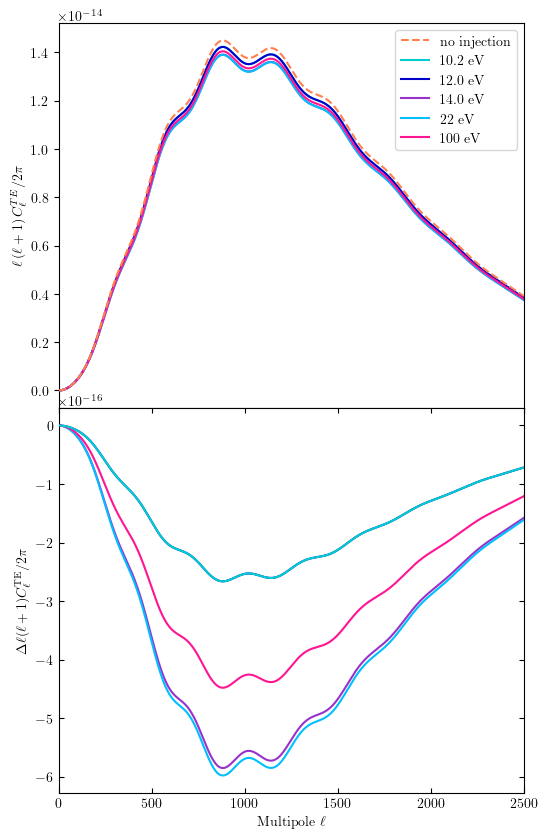

In [102]:
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']

fig = plt.figure(figsize=(6, 10))
gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)


ax1.plot(ell_base, TE_base, color = 'coral', linestyle = '--', label="no injection", zorder = 3)
ax1.plot(ell_dm, TE_dm, color = 'darkturquoise', label="10.2 eV")
ax1.plot(ell_dm_2, TE_dm_2, color = 'mediumblue', label="12.0 eV")
ax1.plot(ell_dm_3, TE_dm_3, color = 'darkorchid', label="14.0 eV")
ax1.plot(ell_dm_4, TE_dm_4, color = 'deepskyblue', label="22 eV")
ax1.plot(ell_dm_5, TE_dm_5, color = 'deeppink', label="100 eV")
ax1.set_ylabel(r'$\ell\left(\ell +1\right)C^{TE}_{\ell}/ 2\pi$')


ax2.plot(ell_dm, TE_dm-TE_base, color = 'darkturquoise', label="10.2 eV", zorder = 3)
ax2.plot(ell_dm_2, TE_dm_2-TE_base, color = 'mediumblue', label="12.0 eV", zorder = 2)
ax2.plot(ell_dm_3, TE_dm_3-TE_base, color = 'darkorchid', label="14.0 eV")
ax2.plot(ell_dm_4, TE_dm_4-TE_base, color = 'deepskyblue', label="22 eV")
ax2.plot(ell_base, TE_dm_5-TE_base, color = 'deeppink', label="100 eV")
ax2.set_xlabel(r'Multipole $\ell$')
ax2.set_ylabel(r'$\Delta \ell(\ell+1)C_\ell^{\mathrm{TE}}/2\pi$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax = plt.gca()
ax.tick_params(direction='in', top=True, right=True)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 2500)
ax1.tick_params(labelbottom=False)
plt.savefig(f'CMB_TE_spectra.pdf', dpi = 700)
plt.show()

## CMB Anisotropies with Planck Data

In [103]:
cl_dm_camb = np.loadtxt("class/output/decay_10.2eV_camb_cl_lensed.dat")
cl_dm_2_camb = np.loadtxt("class/output/decay_14.0eV_camb_cl_lensed.dat")
cl_dm_3_camb = np.loadtxt("class/output/decay_22.0eV_camb_cl_lensed.dat")
cl_planck_TT = np.loadtxt("COM_PowerSpect_CMB-TT-full_R3.01.txt")
cl_planck_EE = np.loadtxt("COM_PowerSpect_CMB-EE-full_R3.01.txt")
cl_planck_TE = np.loadtxt("COM_PowerSpect_CMB-TE-full_R3.01.txt")

ell_planck = cl_planck_TT[:, 0]
TT_planck = cl_planck_TT[:, 1]
TT_planck_derror = cl_planck_TT[:, 2]
TT_planck_uerror = cl_planck_TT[:, 3]

yerr = np.vstack([TT_planck_derror, TT_planck_uerror])

ell_dm_camb = cl_dm_camb[:, 0]
TT_dm_camb = cl_dm_camb[:, 1]

ell_dm_2_camb = cl_dm_2_camb[:, 0]
TT_dm_2_camb = cl_dm_2_camb[:, 1]

ell_dm_3_camb = cl_dm_3_camb[:, 0]
TT_dm_3_camb = cl_dm_3_camb[:, 1]

In [104]:
ell_planck_EE = cl_planck_EE[:, 0]
EE_planck = cl_planck_EE[:, 1]
EE_planck_derror = cl_planck_EE[:, 2]
EE_planck_uerror = cl_planck_EE[:, 3]

yerr_EE = np.vstack([EE_planck_derror, EE_planck_uerror])

EE_dm_camb = cl_dm_camb[:, 2]
EE_dm_2_camb = cl_dm_2_camb[:, 2]
EE_dm_3_camb = cl_dm_3_camb[:, 2]



ell_planck_TE = cl_planck_TE[:, 0]
TE_planck = cl_planck_TE[:, 1]
TE_planck_derror = cl_planck_TE[:, 2]
TE_planck_uerror = cl_planck_TE[:, 3]

yerr_TE = np.vstack([TE_planck_derror, TE_planck_uerror])
TE_dm_camb = cl_dm_camb[:, 4]
TE_dm_2_camb = cl_dm_2_camb[:, 4]
TE_dm_3_camb = cl_dm_3_camb[:, 4]


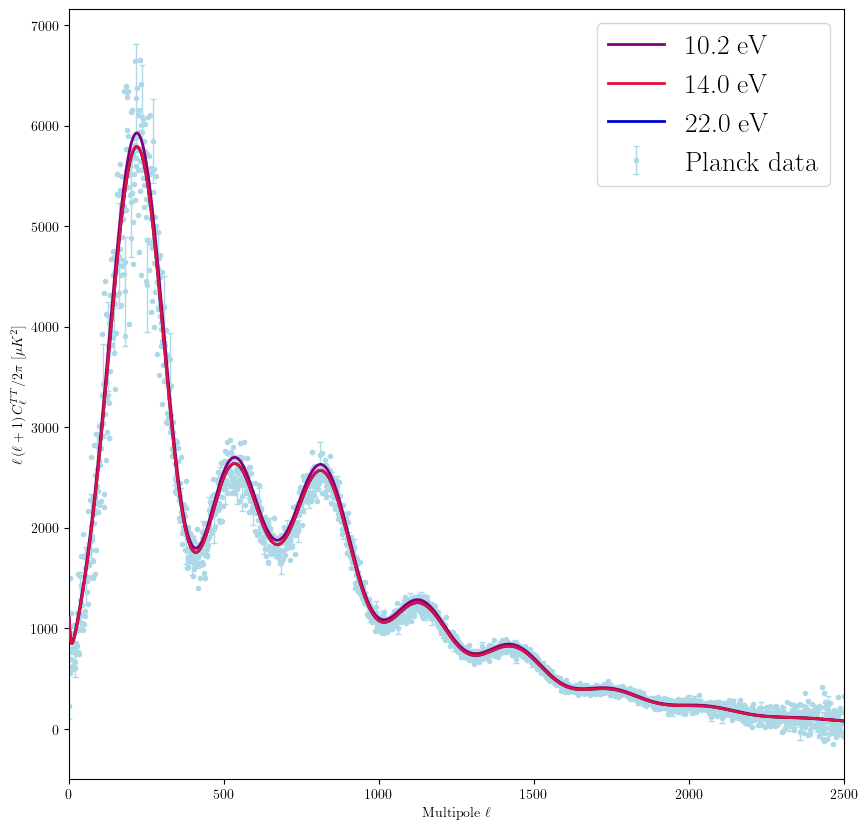

In [105]:
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']

fig = plt.figure(figsize=(10, 10))
#plt.errorbar(ell_planck, TT_planck, yerr=yerr, color = 'mediumblue', label="12.0 eV")
plt.errorbar(
    ell_planck,
    TT_planck,
    yerr=yerr,
    fmt='o',
    ms=3,
    lw=1,
    capsize=2,
    color='lightblue',
    label='Planck data',
    errorevery = 18, 
    zorder=1
)

plt.plot(
    ell_dm_camb,
    TT_dm_camb,
    color='purple',
    label='10.2 eV',
    linewidth=2,
    zorder=3
)

plt.plot(
    ell_dm_2_camb,
    TT_dm_2_camb,
    color='crimson',
    label='14.0 eV',
    linewidth=2,
    zorder=5
)

plt.plot(
    ell_dm_3_camb,
    TT_dm_3_camb,
    color='mediumblue',
    label='22.0 eV',
    linewidth=2,
    zorder=4
)


plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell\left(\ell +1\right)C^{TT}_{\ell}/ 2\pi \ [\mu K^2]$ ')

plt.xlim(0, 2500)
plt.legend(fontsize = 20)
plt.savefig(f'CMB_TT_spectra_wdata.pdf', dpi = 700)


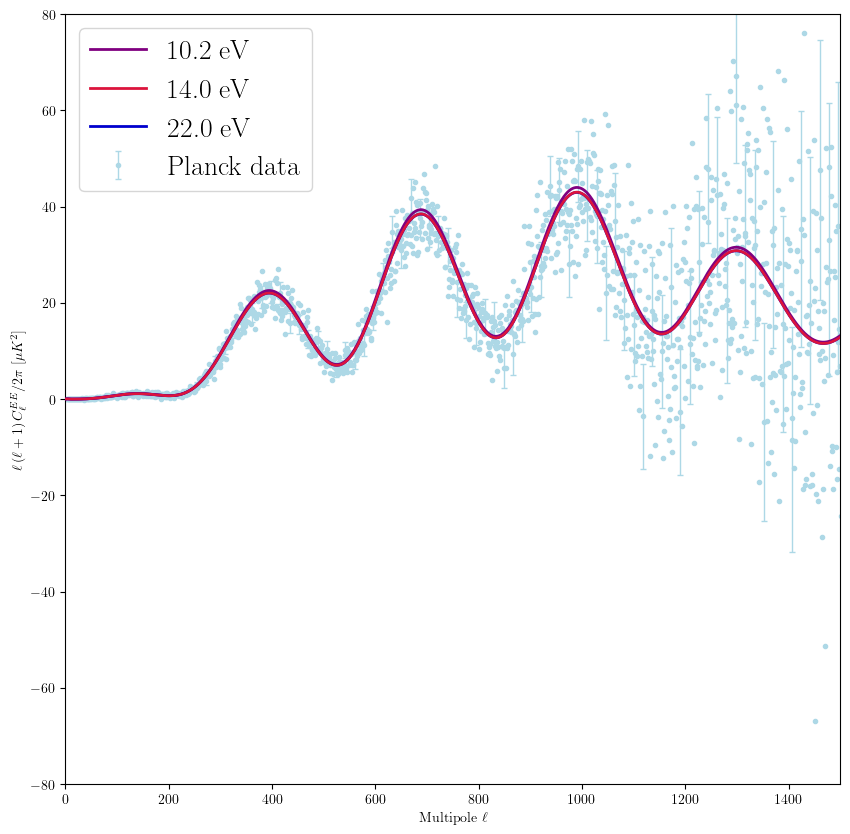

In [106]:
fig = plt.figure(figsize=(10, 10))
plt.errorbar(
    ell_planck_EE,
    EE_planck,
    yerr=yerr_EE,
    fmt='o',
    ms=3,
    lw=1,
    capsize=2,
    color='lightblue',
    label='Planck data',
    errorevery = 18, 
    zorder=1
)

plt.plot(
    ell_dm_camb,
    EE_dm_camb,
    color='purple',
    label='10.2 eV',
    linewidth=2,
    zorder=3
)

plt.plot(
    ell_dm_2_camb,
    EE_dm_2_camb,
    color='crimson',
    label='14.0 eV',
    linewidth=2,
    zorder=5
)

plt.plot(
    ell_dm_3_camb,
    EE_dm_3_camb,
    color='mediumblue',
    label='22.0 eV',
    linewidth=2,
    zorder=4
)


plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell\left(\ell +1\right)C^{EE}_{\ell}/ 2\pi \ [\mu K^2]$ ')

plt.xlim(0, 1500)
plt.ylim(-80, 80)
plt.legend(fontsize = 20)
plt.savefig(f'CMB_EE_spectra_wdata_closeup.pdf', dpi = 700)


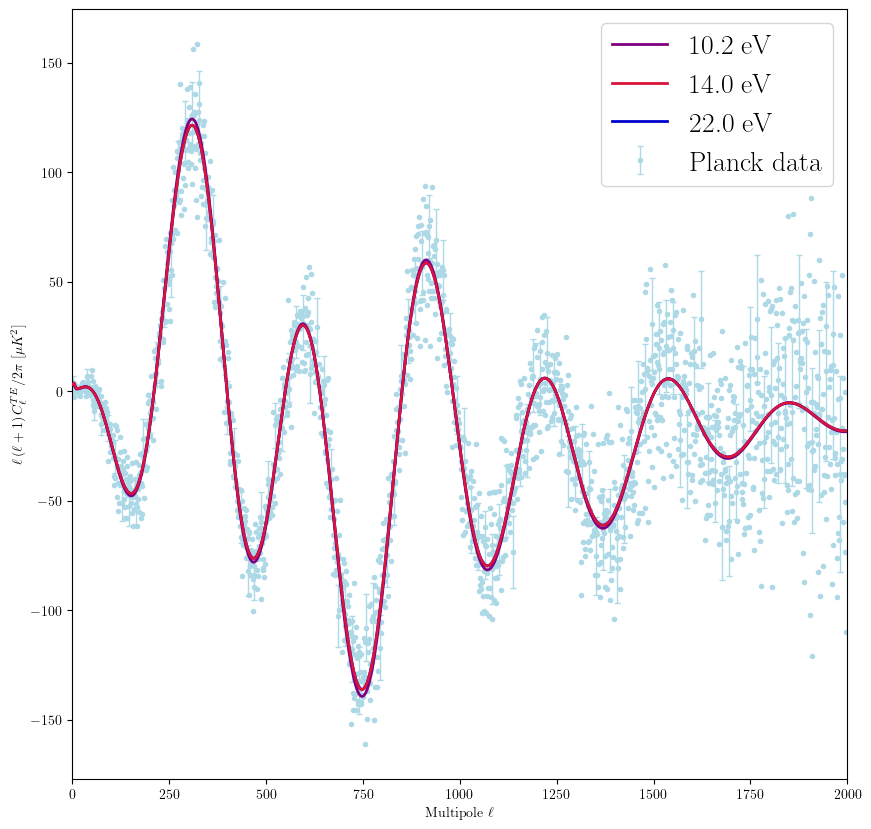

In [109]:
fig = plt.figure(figsize=(10, 10))
plt.errorbar(
    ell_planck_TE,
    TE_planck,
    yerr=yerr_TE,
    fmt='o',
    ms=3,
    lw=1,
    capsize=2,
    color='lightblue',
    label='Planck data',
    errorevery = 18, 
    zorder=1
)

plt.plot(
    ell_dm_camb,
    TE_dm_camb,
    color='purple',
    label='10.2 eV',
    linewidth=2,
    zorder=3
)

plt.plot(
    ell_dm_2_camb,
    TE_dm_2_camb,
    color='crimson',
    label='14.0 eV',
    linewidth=2,
    zorder=5
)

plt.plot(
    ell_dm_3_camb,
    TE_dm_3_camb,
    color='mediumblue',
    label='22.0 eV',
    linewidth=2,
    zorder=4
)


plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell\left(\ell +1\right)C^{TE}_{\ell}/ 2\pi \ [\mu K^2]$ ')

plt.xlim(0, 2000)
#plt.ylim(-80, 80)
plt.legend(fontsize = 20)
plt.savefig(f'CMB_TE_spectra_wdata.pdf', dpi = 700)


## Fisher Forecast

In [112]:
paths = {
    "fid": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_fiducial_cl_lensed.dat",
    "omega_plus": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_omega_dcdmdr_plus_cl_lensed.dat",
    "omega_minus": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_omega_dcdmdr_minus_cl_lensed.dat",
    "tau_plus": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_log10tau_dcdmdr_plus_cl_lensed.dat",
    "tau_minus": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_log10tau_dcdmdr_minus_cl_lensed.dat",
    "As_plus": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_As_plus_cl_lensed.dat",
    "As_minus": "/Users/rxu/Desktop/212_final_proj/class/output/decay_10.2eV_As_minus_cl_lensed.dat",
}

In [ ]:
WORKDIR = "/Users/rxu/Desktop/212_final_proj"

# Fiducial parameter values
Omega0    = 1.0e-3
log10tau0 = np.log10(3.0e25)
As0       = np.exp(3.044) / 1e10

# Finite-difference steps for calculating derivatives 
dOmega    = 5.0e-4
dlog10tau = 0.05
dAs       = 0.05 * As0

# CLASS format -> microK^2 conversion
TCMB_K       = 2.7255
CLASS_TO_uK2 = (TCMB_K * 1e6) ** 2


# helpers to load class files 

def load_cls_class_to_uK2(path):
    arr = np.loadtxt(path)
    ell = arr[:, 0]
    TT  = arr[:, 1] * CLASS_TO_uK2
    EE  = arr[:, 2] * CLASS_TO_uK2
    TE  = arr[:, 3] * CLASS_TO_uK2
    return ell, TT, EE, TE

# Every ExoCLASS file generated for this project has the same shape of multipoles, but just in case
def truncate_to_common_ell(*cls_sets):
    min_len = min(len(x[0]) for x in cls_sets)
    return [(ell[:min_len], TT[:min_len], EE[:min_len], TE[:min_len])
            for ell, TT, EE, TE in cls_sets]


# build derivatives (NOT in log space)

def build_three_param_derivatives(paths):
    fid, op, om, tp, tm, ap, am = truncate_to_common_ell(
        load_cls_class_to_uK2(paths["fid"]),
        load_cls_class_to_uK2(paths["omega_plus"]),
        load_cls_class_to_uK2(paths["omega_minus"]),
        load_cls_class_to_uK2(paths["tau_plus"]),
        load_cls_class_to_uK2(paths["tau_minus"]),
        load_cls_class_to_uK2(paths["As_plus"]),
        load_cls_class_to_uK2(paths["As_minus"]),
    )

    ell,  TT_fid, EE_fid, TE_fid = fid
    _, TT_op,  EE_op,  TE_op  = op
    _, TT_om,  EE_om,  TE_om  = om
    _, TT_tp,  EE_tp,  TE_tp  = tp
    _, TT_tm,  EE_tm,  TE_tm  = tm
    _, TT_ap,  EE_ap,  TE_ap  = ap
    _, TT_am,  EE_am,  TE_am  = am

    return {
        "ell":    ell,
        "TT_fid": TT_fid,
        "EE_fid": EE_fid,
        "TE_fid": TE_fid,

        # dC/dOmega 
        "dTT_dOmega":   (TT_op - TT_om) / (2.0 * dOmega),
        "dEE_dOmega":   (EE_op - EE_om) / (2.0 * dOmega),
        "dTE_dOmega":   (TE_op - TE_om) / (2.0 * dOmega),

        # dC/d(log10 tau) 
        "dTT_dlogtau":  (TT_tp - TT_tm) / (2.0 * dlog10tau),
        "dEE_dlogtau":  (EE_tp - EE_tm) / (2.0 * dlog10tau),
        "dTE_dlogtau":  (TE_tp - TE_tm) / (2.0 * dlog10tau),

        # dC/dAs
        "dTT_dAs":      (TT_ap - TT_am) / (2.0 * dAs),
        "dEE_dAs":      (EE_ap - EE_am) / (2.0 * dAs),
        "dTE_dAs":      (TE_ap - TE_am) / (2.0 * dAs),
    }



# helper functions to reparameterize to log space (log10 Omega, log10 tau, ln As) through the chain rule 

# Chain rule:  dC/d(phi_i) = dC/d(theta_i) * d(theta_i)/d(phi_i)
#
#   theta_1 = log10(Omega)   =>  d(Omega)/d(log10 Omega) = Omega * ln(10)
#   theta_2 = log10(tau)     =>  already log – Jacobian = 1
#   theta_3 = ln(10^10 As)  =>  d(As)/d(ln As) = As
#


def reparametrize_derivs(derivs):
    ln10 = np.log(10.0)

    jac_omega = Omega0 * ln10   # d Omega / d log10_Omega
    jac_tau   = 1.0             # d log10_tau / d log10_tau
    jac_As    = As0             # d As / d ln(10^10 As)

    d = dict(derivs)

    for spec in ("TT", "EE", "TE"):
        d[f"d{spec}_dlog10Omega"] = derivs[f"d{spec}_dOmega"]  * jac_omega
        d[f"d{spec}_dlogtau"]     = derivs[f"d{spec}_dlogtau"] * jac_tau   # no-op
        d[f"d{spec}_dlnAs"]       = derivs[f"d{spec}_dAs"]     * jac_As

    return d


# Helper functions to create Fisher matrix in log space

def covariance_matrix_TT_EE_TE(CTT, CEE, CTE, ell, f_sky=0.65):
    pref = 2.0 / ((2.0 * ell + 1.0) * f_sky)
    return pref * np.array([
        [CTT**2,    CTE**2,              CTT * CTE                 ],
        [CTE**2,    CEE**2,              CEE * CTE                 ],
        [CTT*CTE,   CEE*CTE,  0.5*(CTE**2 + CTT*CEE)              ],
    ])


def fisher_3param_TT_EE_TE(derivs, ell_min=2, ell_max=2500, f_sky=0.65):
    """
    Build the 3x3 Fisher matrix in the reparametrized basis:
      theta = (log10 Omega, log10 tau, ln(10^10 As))
    """
    d = reparametrize_derivs(derivs)

    ell = d["ell"]
    TT  = d["TT_fid"]
    EE  = d["EE_fid"]
    TE  = d["TE_fid"]

    # derivative vectors
    param_keys = [
        ("dTT_dlog10Omega", "dEE_dlog10Omega", "dTE_dlog10Omega"),
        ("dTT_dlogtau",     "dEE_dlogtau",     "dTE_dlogtau"    ),
        ("dTT_dlnAs",       "dEE_dlnAs",        "dTE_dlnAs"      ),
    ]

    F = np.zeros((3, 3), dtype=float)

    for i, l in enumerate(ell):
        if l < ell_min or l > ell_max:
            continue

        cov    = covariance_matrix_TT_EE_TE(TT[i], EE[i], TE[i], l, f_sky=f_sky)
        invcov = np.linalg.inv(cov)

        dvecs = [np.array([d[kTT][i], d[kEE][i], d[kTE][i]])
                 for kTT, kEE, kTE in param_keys]

        for a in range(3):
            for b in range(3):
                F[a, b] += dvecs[a] @ invcov @ dvecs[b]

    return F


# wrap into CosmicFish and summary (for pretty plots and more organized structure)

def wrap_with_cosmicfish(F):
    mpl.rcParams["text.usetex"]      = False
    mpl.rcParams["font.family"]      = "serif"
    mpl.rcParams["mathtext.fontset"] = "cm"

    fish = fm.fisher_matrix(
        fisher_matrix      = F,
        param_names        = ["log10Omega_dcdmdr", "log10tau_dcdm", "lnAs"],
        param_names_latex  = [
            r"\log_{10}\Omega_{\rm dcdmdr}",
            r"\log_{10}\tau_{\rm dcdm}",
            r"\ln(10^{10}A_s)",
        ],
        fiducial = [
            np.log10(Omega0),
            log10tau0,
            np.log(1e10 * As0),   
        ],
    )
    return fish


def summarize_cosmicfish(fish):
    F    = fish.get_fisher_matrix()
    Cov  = fish.get_fisher_inverse()
    names = fish.get_param_names()
    fid   = fish.get_param_fiducial()

    print("Fisher matrix (reparametrized):\n", F)
    print("\nCovariance matrix:\n", Cov)
    print("\nParameter summary:")
    for i, name in enumerate(names):
        sigma_unmarg = 1.0 / np.sqrt(F[i, i])
        sigma_marg   = np.sqrt(Cov[i, i])
        print(f"  {name}: fid={fid[i]:.6e}, "
              f"sigma_unmarg={sigma_unmarg:.6e}, sigma_marg={sigma_marg:.6e}")

    corr = Cov / np.sqrt(np.outer(np.diag(Cov), np.diag(Cov)))
    print("\nCorrelation matrix:\n", corr)
    return Cov, corr


# helpers to marginalize over ln As and plot (Omega, tau) ELLIPSE

def plot_cosmicfish_dm_ellipse(fish3, out_png=None):
    """Marginalize over ln(10^10 As), plot log10Omega vs log10tau."""
    fish2 = fo.marginalise(fish3, ["log10Omega_dcdmdr", "log10tau_dcdm"])

    analysis = fpa.CosmicFish_FisherAnalysis(fisher_list=[fish2])
    plotter  = fp.CosmicFishPlotter(fishers=analysis)

    plotter.new_plot()
    plotter.plot_tri()

    if out_png is not None:
        try:
            plotter.figure.savefig(out_png, dpi=200, bbox_inches="tight")
        except AttributeError:
            pass

    return fish2, plotter


# main function that incorporates entire three parameter Fisher forecast

def run_three_param_forecast_from_files(paths, energy_eV,
                                        ell_min=2, ell_max=2500, f_sky=0.65):
    derivs  = build_three_param_derivatives(paths)
    F       = fisher_3param_TT_EE_TE(derivs, ell_min=ell_min,
                                     ell_max=ell_max, f_sky=f_sky)
    fish3   = wrap_with_cosmicfish(F)
    Cov, corr = summarize_cosmicfish(fish3)

    fish2, plotter = plot_cosmicfish_dm_ellipse(
        fish3,
        out_png=os.path.join(WORKDIR, f"fisher_{energy_eV:.1f}eV_margAs.png"), # Fisher ellipse is saved to files
    )

    return {
        "paths":         paths,
        "derivs":        derivs,
        "F":             F,
        "fish3":         fish3,
        "fish2_marg_As": fish2,
        "Cov":           Cov,
        "corr":          corr,
        "plotter":       plotter,
    }

In [125]:
result_10_2 = run_three_param_forecast_from_files(paths, energy_eV=10.2)

Fisher matrix (reparametrized):
 [[6.49271529e-04 2.93849053e-04 3.05260290e+01]
 [2.93849053e-04 7.04300844e-03 6.08504929e+01]
 [3.05260290e+01 6.08504929e+01 4.28308095e+06]]

Covariance matrix:
 [[ 2.33348351e+03  5.28144123e+01 -1.73813592e-02]
 [ 5.28144123e+01  1.63047086e+02 -2.69285356e-03]
 [-1.73813592e-02 -2.69285356e-03  3.95613662e-07]]

Parameter summary:
  log10Omega_dcdmdr: fid=-3.000000e+00, sigma_unmarg=3.924522e+01, sigma_marg=4.830614e+01
  log10tau_dcdm: fid=2.547712e+01, sigma_unmarg=1.191574e+01, sigma_marg=1.276899e+01
  lnAs: fid=3.044000e+00, sigma_unmarg=4.831944e-04, sigma_marg=6.289783e-04

Correlation matrix:
 [[ 1.          0.08562362 -0.57206546]
 [ 0.08562362  1.         -0.33528998]
 [-0.57206546 -0.33528998  1.        ]]
